Mounted at /content/drive
Copying refined SOS to local SSD...
Copy complete.
Validation samples: 1615
Device: cuda
Model loaded: /content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/DeeplabV3_finetuned.pth


100%|██████████| 202/202 [00:37<00:00,  5.37it/s]


Final Validation Metrics
Accuracy : 0.9283
Recall   : 0.9232
Precision: 0.8306
F1       : 0.8744
IoU      : 0.7769
FPR      : 0.0698
Confusion Matrix
TP = 26430179
TN = 71820021
FP = 5391495
FN = 2198945


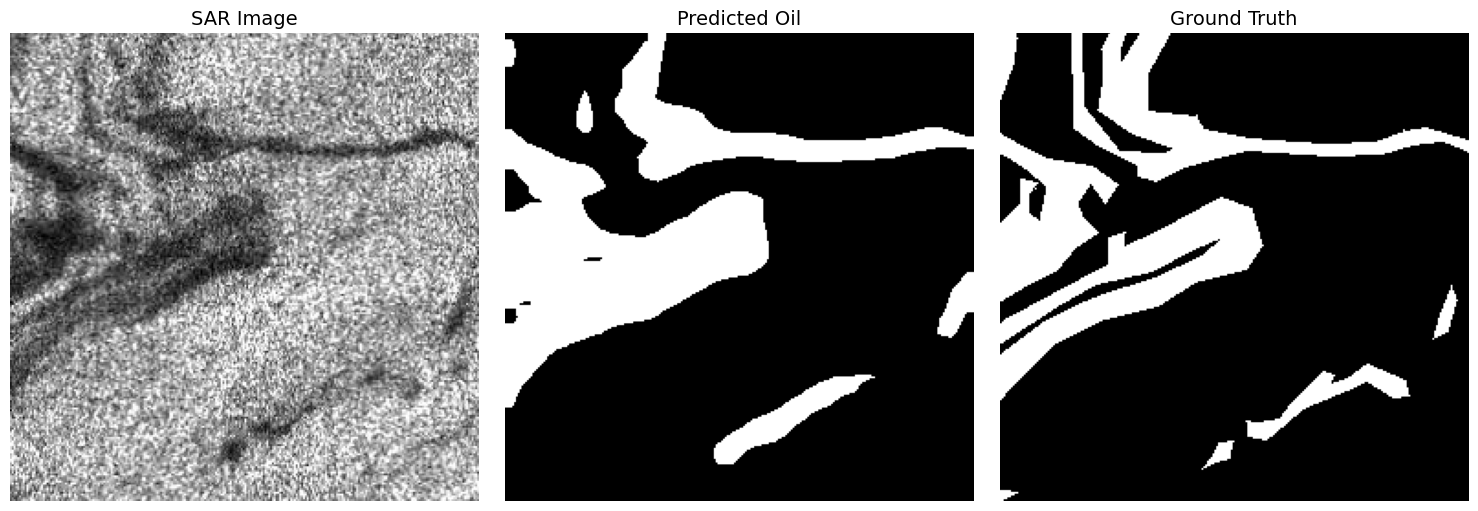

Saved figure: /content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/stage2_deeplabv3_finetuning_example.png


In [ ]:
# ============================================================
# Evaluate_model.ipynb

# Evaluate a trained DeepLabV3 model on the Refined SOS validation dataset and generate quantitative performance metrics.

# Functions:

# - Load a trained DeepLabV3 checkpoint
# - Evaluate on the Refined SOS validation set
# - Compute confusion matrix statistics
# - Calculate segmentation metrics
#   - Accuracy
#   - Recall
#   - Precision
#   - F1 Score
#   - Intersection over Union (IoU)
#   - False Positive Rate (FPR)
# - Generate prediction visualization examples
# - Export validation figures for documentation and comparison
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50

# ============================================================
# Paths
# ============================================================

drive_base = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection"

model_path = os.path.join(
    drive_base,
    "DeeplabV3_finetuned.pth"
)

local_root = "/content/refined SOS"

if not os.path.exists(local_root):
    print("Copying refined SOS to local SSD...")
    shutil.copytree(
        os.path.join(drive_base, "refined SOS"),
        local_root
    )
    print("Copy complete.")
else:
    print("Local dataset already exists.")

val_image_dir = os.path.join(local_root, "images", "val")
val_mask_dir  = os.path.join(local_root, "masks",  "val")

save_fig_path = os.path.join(
    drive_base,
    "stage2_deeplabv3_finetuning_example.png"
)

# ============================================================
# Dataset
# ============================================================

class OilSpillDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = Image.open(img_path).convert("L")
        image = np.array(image, dtype=np.float32) / 255.0
        image = np.stack([image, image, image], axis=0)
        image = torch.from_numpy(image).float()

        mask = Image.open(mask_path).convert("L")
        mask = np.array(mask)
        mask = (mask > 0).astype(np.uint8)
        mask = torch.from_numpy(mask).long()

        return image, mask

val_dataset = OilSpillDataset(val_image_dir, val_mask_dir)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Validation samples:", len(val_dataset))

# ============================================================
# Load model
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = deeplabv3_resnet50(
    weights=None,
    weights_backbone=None,
    num_classes=2,
    aux_loss=False
)

state = torch.load(model_path, map_location=device)

if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

model.load_state_dict(state, strict=True)
model = model.to(device)
model.eval()

print("Model loaded:", model_path)

# ============================================================
# Validation metrics
# ============================================================

TP = 0
TN = 0
FP = 0
FN = 0

with torch.no_grad():

    for images, masks in tqdm(val_loader):

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)["out"]
        preds = torch.argmax(outputs, dim=1)

        preds = preds.cpu().numpy().astype(np.uint8)
        masks = masks.cpu().numpy().astype(np.uint8)

        TP += np.sum((preds == 1) & (masks == 1))
        TN += np.sum((preds == 0) & (masks == 0))
        FP += np.sum((preds == 1) & (masks == 0))
        FN += np.sum((preds == 0) & (masks == 1))

accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-8)
recall    = TP / (TP + FN + 1e-8)
precision = TP / (TP + FP + 1e-8)
f1        = 2 * precision * recall / (precision + recall + 1e-8)
iou       = TP / (TP + FP + FN + 1e-8)
fpr       = FP / (FP + TN + 1e-8)

print("=" * 40)
print("Final Validation Metrics")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1       : {f1:.4f}")
print(f"IoU      : {iou:.4f}")
print(f"FPR      : {fpr:.4f}")

print("=" * 40)
print("Confusion Matrix")
print("=" * 40)
print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

# ============================================================
# Visualization example
# ============================================================

sample_idx = 0   # 원하는 validation sample 번호로 변경 가능

test_img, test_mask = val_dataset[sample_idx]

with torch.no_grad():
    input_tensor = test_img.unsqueeze(0).to(device)
    output = model(input_tensor)["out"]
    pred = torch.argmax(output, dim=1)

pred_np = pred.squeeze().cpu().numpy()
img_np = test_img[0].cpu().numpy()
mask_np = test_mask.cpu().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title("SAR Image", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_np, cmap="gray")
plt.title("Predicted Oil", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.savefig(save_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", save_fig_path)